# etl.py

In [1]:
import pandas as pd
import re

df = pd.read_csv("concert_tours_by_women.csv")

df.columns = [col.strip() for col in df.columns]

df[['Start year', 'End year']] = df['Year(s)'].str.extract(r'(\d{4})(?:–|-)?(\d{4})?')
df['End year'] = df['End year'].fillna(df['Start year'])

df['Start year'] = df['Start year'].astype(int)
df['End year'] = df['End year'].astype(int)

df = df.dropna(subset=[
    'Actual gross', 
    'Adjustedgross (in 2022 dollars)', 
    'Artist', 
    'Tour title', 
    'Shows', 
    'Average gross', 
    'Start year', 
    'End year'
])

def to_float(val):
    if isinstance(val, str):
        cleaned = re.sub(r"[^\d.]", "", val)
        return float(cleaned) if cleaned else 0.0
    return val

df['Actual gross'] = df['Actual gross'].apply(to_float)
df['Adjustedgross (in 2022 dollars)'] = df['Adjustedgross (in 2022 dollars)'].apply(to_float)
df['Average gross'] = df['Average gross'].apply(to_float)
df['Shows'] = df['Shows'].astype(int)

df = df.rename(columns={"Adjustedgross (in 2022 dollars)": "Adjusted gross (in 2022 dollars)"})

df = df.sort_values(by="Adjusted gross (in 2022 dollars)", ascending=False).reset_index(drop=True)

df["Rank"] = df.index + 1

colunas_desejadas = [
    "Rank",
    "Actual gross",
    "Adjusted gross (in 2022 dollars)",
    "Artist",
    "Tour title",
    "Shows",
    "Average gross",
    "Start year",
    "End year"
]

tabela_filtrada = df[colunas_desejadas]

display(tabela_filtrada)

,Rank,Actual gross,Adjusted gross (in 2022 dollars),Artist,Tour title,Shows,Average gross,Start year,End year
0,1,780000000.0,780000000.0,Taylor Swift,The Eras Tour †,56,13928571.0,2023,2024
1,2,579800000.0,579800000.0,Beyoncé,Renaissance World Tour,56,10353571.0,2023,2023
2,3,411000000.0,560622615.0,Madonna,Sticky & Sweet Tour ‡[4][a],85,4835294.0,2008,2009
3,4,397300000.0,454751555.0,Pink,Beautiful Trauma World Tour,156,2546795.0,2018,2019
4,5,345675146.0,402844849.0,Taylor Swift,Reputation Stadium Tour,53,6522173.0,2018,2018
5,6,305158363.0,388978496.0,Madonna,The MDNA Tour,88,3467709.0,2012,2012
6,7,280000000.0,381932682.0,Celine Dion,Taking Chances World Tour,131,2137405.0,2008,2009
7,8,256084556.0,312258401.0,Beyoncé,The Formation World Tour,49,5226215.0,2016,2016
8,9,250400000.0,309141878.0,Taylor Swift,The 1989 World Tour,85,2945882.0,2015,2015
9,10,200000000.0,299676265.0,Cher,Living Proof: The Farewell Tour ‡[21][a],325,615385.0,2002,2005


# job.py

Q1: Taylor Swift com média de $381,518,786.50

Q2: Renaissance World Tour (Beyoncé) com média de $10,353,571.00

Q3: Top 3 turnês com maior valor por show:
- The Eras Tour † (Taylor Swift) - $13,928,571.43
- Renaissance World Tour (Beyoncé) - $10,353,571.43
- Reputation Stadium Tour (Taylor Swift) - $7,600,846.21



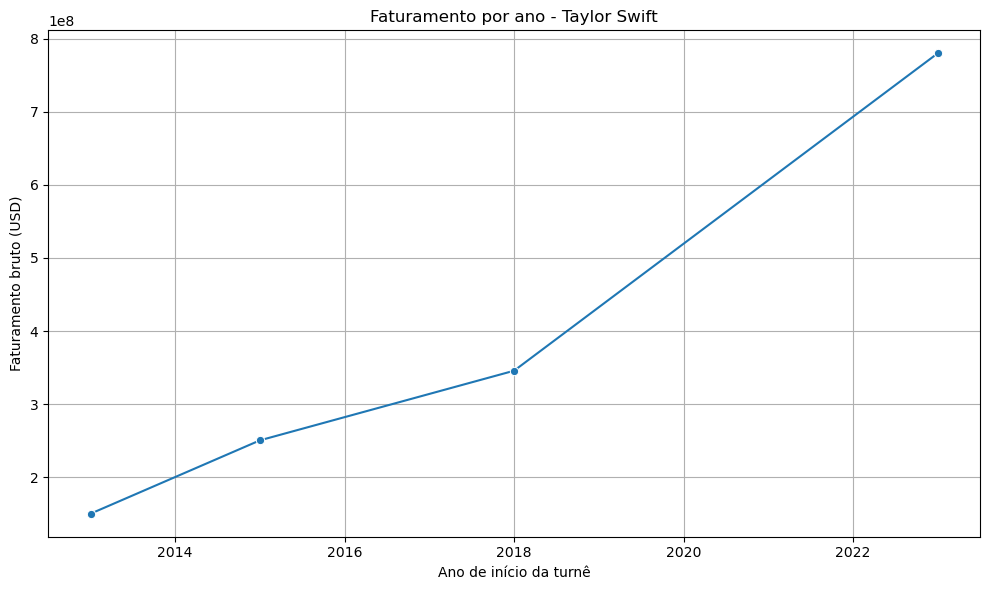

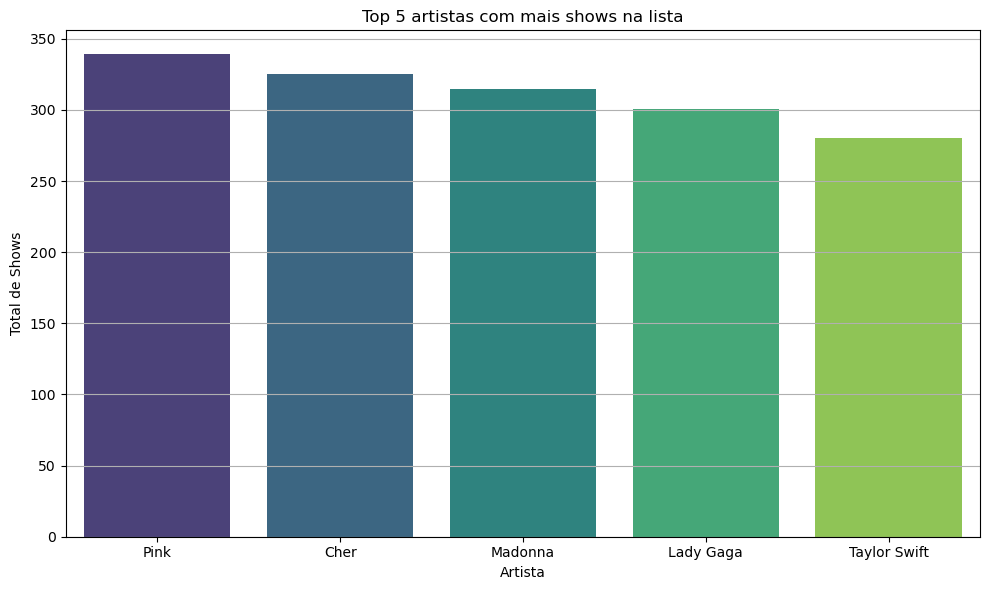

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar dados
df = pd.read_csv("csv_limpo.csv")

# Criar nova coluna
df["valor_por_show"] = df["Adjusted gross (in 2022 dollars)"] / df["Shows"]

# Q1 — Artista mais frequente e sua média de faturamento
most_common_artist = df["Artist"].value_counts().idxmax()
media = df[df["Artist"] == most_common_artist]["Actual gross"].mean()
print(f"Q1: {most_common_artist} com média de ${media:,.2f}\n")

# Q2 — Melhor turnê de apenas um ano
one_year = df[df["Start year"] == df["End year"]]
melhor = one_year.loc[one_year["Average gross"].idxmax()]
print(f"Q2: {melhor['Tour title']} ({melhor['Artist']}) com média de ${melhor['Average gross']:,.2f}\n")

# Q3 — Top 3 turnês com maior valor por show
top3 = df.nlargest(3, "valor_por_show")[["Tour title", "Artist", "valor_por_show"]]
print("Q3: Top 3 turnês com maior valor por show:")
for _, row in top3.iterrows():
    print(f"- {row['Tour title']} ({row['Artist']}) - ${row['valor_por_show']:,.2f}")
print()

# Q4 — Gráfico de linha: Faturamento por ano do artista mais frequente
df_artista = df[df["Artist"] == most_common_artist]
faturamento_ano = df_artista.groupby("Start year")["Actual gross"].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=faturamento_ano, x="Start year", y="Actual gross", marker="o")
plt.title(f"Faturamento por ano - {most_common_artist}")
plt.xlabel("Ano de início da turnê")
plt.ylabel("Faturamento bruto (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Q5 — Gráfico de barras: Top 5 artistas com mais shows
top5_artistas = df.groupby("Artist")["Shows"].sum().nlargest(5).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=top5_artistas, x="Artist", y="Shows", hue="Artist", palette="viridis", legend=False)
plt.title("Top 5 artistas com mais shows na lista")
plt.xlabel("Artista")
plt.ylabel("Total de Shows")
plt.grid(axis="y")
plt.tight_layout()
plt.show()
